# *MLP Clasificador de Movimientos*

### Parte 1 - Preparación de los Datos

Para empezar, importar los archivos de excel del repositorio.

Se almacenan en variables los nombres relevantes a la información de los Excel.

In [ ]:
import pandas as pd
import numpy as np

archivos = ["IMEC2540L_DatosLab2_1.xlsx","IMEC2540L_DatosLab2_2.xlsx","IMEC2540L_DatosLab2_3.xlsx"]

aceleraciones = {('IMEC2540L_DatosLab2_1.xlsx','Prueba 1'):'Angelito',('IMEC2540L_DatosLab2_1.xlsx','Prueba 2'):'Sentadilla',
                 ('IMEC2540L_DatosLab2_1.xlsx','Prueba 3'):'Angelito',('IMEC2540L_DatosLab2_1.xlsx','Prueba 4'):'Sentadilla',('IMEC2540L_DatosLab2_1.xlsx','Prueba 5'):'Angelito',
                 ('IMEC2540L_DatosLab2_2.xlsx','Angelitos'):'Angelito',('IMEC2540L_DatosLab2_2.xlsx','sentadilla 1'):'Sentadilla', ('IMEC2540L_DatosLab2_2.xlsx','Angelitos 2'):'Angelito',
                 ('IMEC2540L_DatosLab2_2.xlsx','Sentadilla 2'):'Sentadilla',('IMEC2540L_DatosLab2_2.xlsx','Angelito 3'):'Angelito', ('IMEC2540L_DatosLab2_2.xlsx','Sentadilla 3'):'Sentadilla',
                 ('IMEC2540L_DatosLab2_2.xlsx','Angelito 4'):'Angelito', ('IMEC2540L_DatosLab2_2.xlsx','Angelito 5'):'Angelito', ('IMEC2540L_DatosLab2_2.xlsx','Sentadilla 4'):'Sentadilla',
                 ('IMEC2540L_DatosLab2_2.xlsx','Angelito 6'):'Angelito', ('IMEC2540L_DatosLab2_2.xlsx','Sentadilla 5'):'Sentadilla', ('IMEC2540L_DatosLab2_2.xlsx','Angelito 7'):'Angelito',
                 ('IMEC2540L_DatosLab2_2.xlsx','Sentadilla 6'):'Sentadilla',('IMEC2540L_DatosLab2_2.xlsx','Sentadilla 7'):'Sentadilla', ('IMEC2540L_DatosLab2_2.xlsx','Sentadilla 8'):'Sentadilla',
                 ('IMEC2540L_DatosLab2_2.xlsx','Nazi 1'):'Saludo', ('IMEC2540L_DatosLab2_2.xlsx','Nazi 2'):'Saludo', ('IMEC2540L_DatosLab2_2.xlsx','Nazi 3'):'Saludo', ('IMEC2540L_DatosLab2_2.xlsx','Nazi 4'):'Saludo',
                 ('IMEC2540L_DatosLab2_2.xlsx','Nazi 5'):'Saludo', ('IMEC2540L_DatosLab2_2.xlsx','Nazi 6'):'Saludo', ('IMEC2540L_DatosLab2_2.xlsx','Nazi 7'):'Saludo', ('IMEC2540L_DatosLab2_2.xlsx','Nazi 8'):'Saludo',
                 ('IMEC2540L_DatosLab2_2.xlsx','Nazi 9'):'Saludo', ('IMEC2540L_DatosLab2_2.xlsx','Nazi 10'):'Saludo',('IMEC2540L_DatosLab2_3.xlsx','T1'):'Quieto',
                 ('IMEC2540L_DatosLab2_3.xlsx','T2'):'Quieto',('IMEC2540L_DatosLab2_3.xlsx','T3'):'Quieto',('IMEC2540L_DatosLab2_3.xlsx','T4'):'Quieto', ('IMEC2540L_DatosLab2_3.xlsx','T5'):'Quieto',
                 ('IMEC2540L_DatosLab2_3.xlsx','T6'):'Quieto',('IMEC2540L_DatosLab2_3.xlsx','T7'):'Quieto',('IMEC2540L_DatosLab2_3.xlsx','T8'):'Quieto', ('IMEC2540L_DatosLab2_3.xlsx','T9'):'Quieto',
                 ('IMEC2540L_DatosLab2_3.xlsx','T10'):'Quieto'}

col_tiempo = "Tiempo (s)"

cols_aceleraciones = ["AccX (m/s²)","AccY (m/s²)","AccZ (m/s²)"]

acciones = ['Angelito','Sentadilla','Saludo','Quieto']



Se crea una función para limpiar los datos de la información innecesaria y crear df con únicamente información útil.

In [ ]:
def limpiar(df):
    df = df[[col_tiempo] + cols_aceleraciones].copy() # Ignora los timestamps

    for c in [col_tiempo] + cols_aceleraciones:   # Se convierte la información de texto a numérica
        if df[c].dtype == object:
            df[c] = df[c].astype(str).str.replace(",", ".", regex=False)
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna() # Se eliminan las filas con información inválida

    df = df.drop_duplicates(subset=col_tiempo).sort_values(col_tiempo) # Se eliminan los repetidos y se ordena
    return df.reset_index(drop=True)

Ahora se lee cada una de las hojas de los Excel y se extrae respectivamente su información en un df perteneciente a una lista de series

In [ ]:
series = []   #(df_limpio, etiqueta, id_serie)

for arch in archivos:
    hojas = pd.read_excel(arch, sheet_name=None)   # {nombre_hoja: df}

    for nombre, df in hojas.items():
        if (arch, nombre) not in aceleraciones:
            print(f"AVISO: {arch} | {nombre} no está en MAPA, se omite")
            continue # Continue hace que pare aca la iteración y vaya directamente a la siguiente, pues no está esa hoja
        etiqueta = aceleraciones[(arch, nombre)]

        # Convertir primero el tiempo a número para detectar reinicios
        t = pd.to_numeric(
            df[col_tiempo].astype(str).str.replace(",", ".", regex=False),
            errors="coerce")
        df = df.assign(**{col_tiempo: t}).dropna(subset=[col_tiempo])
        df["serie_n"] = (df[col_tiempo].diff() < 0).cumsum()

        for n, sub in df.groupby("serie_n"):
            sub = limpiar(sub.drop(columns="serie_n"))
            if len(sub) < 50:    # trozos demasiado cortos
                continue
            id_serie = f"{arch}:{nombre}:{n}"
            series.append((sub, etiqueta, id_serie))

AVISO: IMEC2540L_DatosLab2_1.xlsx | Resumen General no está en MAPA, se omite
AVISO: IMEC2540L_DatosLab2_2.xlsx | Resumen no está en MAPA, se omite


In [ ]:
print(f"Total de series: {len(series)}")

Total de series: 40


In [ ]:
print(series)

[(      Tiempo (s)  AccX (m/s²)  AccY (m/s²)  AccZ (m/s²)
0          0.000    -1.702277     6.969521     6.734890
1          0.051    -1.642422     7.010222     6.734890
2          0.111    -1.666364     6.955156     6.696582
3          0.171    -1.845930     6.873753     6.787562
4          0.231    -1.642422     6.782773     6.701371
...          ...          ...          ...          ...
6870      97.915    -4.747702     4.771644     7.096414
6871      97.934    -4.747702     4.771644     7.199365
6872      97.935    -4.833893     4.927267     7.199365
6873      97.955    -4.833893     4.927267     7.213730
6874      97.956    -4.740520     4.714183     7.213730

[6875 rows x 4 columns], 'Angelito', 'IMEC2540L_DatosLab2_1.xlsx:Prueba 1:0'), (      Tiempo (s)  AccX (m/s²)  AccY (m/s²)  AccZ (m/s²)
0          0.000    -4.022259     5.566519     6.931214
1          0.057    -4.022259     5.566519     6.833052
2          0.058    -3.983952     5.590461     6.833052
3          0.116    -

### Parte 2 - Filtrado de Datos

A continuación, se procede a aplicar los respectivos filtros a los datos de interés, siendo estos:

A.) Filtro Pasa-Bajas: Corta las señales saturadas (En este caso mayores a 4Hz)

B.) Promedio Movil por Ejes: Suaviza la función utilizando un promedio basado en los datos vecinos

C.) Remuestreo: Se interpolan los datos para que las series de tiempo manejen intervalos constantes

In [ ]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt

FS = 20          # frecuencia a la que remuestreas (Hz)
FC = 5.0         # corte del pasa-bajos (Hz)
VENT_PM = 5      # muestras del promedio móvil (5 muestras = 0,25 s a 20 Hz) / Estas son las muestras que se promedian para suavizar las curvas

def filtro_paso_bajo(signal, cutoff, fs, order=4):
    b, a = butter(order, cutoff / (0.5 * fs), btype="low")
    return filtfilt(b, a, signal, axis=0)

def promedio_movil(X, ventana=VENT_PM):
    # Promedia cada eje por separado sin desfase (center = True)
    return (pd.DataFrame(X).rolling(window=ventana, center=True, min_periods=1).mean().values)

def remuestrear_y_filtrar(df):
    t = df[col_tiempo].values
    t_unif = np.arange(t[0], t[-1], 1 / FS)  # Establece los valores equiespaciados del tiempo
    X = np.column_stack([np.interp(t_unif, t, df[c].values) for c in cols_aceleraciones])  # Interpola para dichos tiempos equiespaciados
    Xf = filtro_paso_bajo(X, FC, FS)         # pasa-bajos en los 3 ejes
    Xs = promedio_movil(Xf)               # promedio móvil por eje
    return t_unif, Xf, Xs

series_filt = []
for df, etiqueta, id_serie in series:
    t_unif, Xf, Xs = remuestrear_y_filtrar(df)  #
    series_filt.append((t_unif, Xs, etiqueta, id_serie))          # se guarda la señal suavizada
    print(id_serie, Xs.shape)

IMEC2540L_DatosLab2_1.xlsx:Prueba 1:0 (1960, 3)
IMEC2540L_DatosLab2_1.xlsx:Prueba 2:0 (1676, 3)
IMEC2540L_DatosLab2_1.xlsx:Prueba 3:0 (1401, 3)
IMEC2540L_DatosLab2_1.xlsx:Prueba 4:0 (1437, 3)
IMEC2540L_DatosLab2_1.xlsx:Prueba 5:0 (1596, 3)
IMEC2540L_DatosLab2_2.xlsx:Angelitos:0 (1473, 3)
IMEC2540L_DatosLab2_2.xlsx:sentadilla 1:0 (1428, 3)
IMEC2540L_DatosLab2_2.xlsx:Angelitos 2:0 (1958, 3)
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 2:0 (1608, 3)
IMEC2540L_DatosLab2_2.xlsx:Angelito 3:0 (1524, 3)
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 3:0 (1658, 3)
IMEC2540L_DatosLab2_2.xlsx:Angelito 4:0 (1599, 3)
IMEC2540L_DatosLab2_2.xlsx:Angelito 5:0 (1445, 3)
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 4:0 (1379, 3)
IMEC2540L_DatosLab2_2.xlsx:Angelito 6:0 (1368, 3)
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 5:0 (1348, 3)
IMEC2540L_DatosLab2_2.xlsx:Angelito 7:0 (1386, 3)
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 6:0 (1448, 3)
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 7:0 (1282, 3)
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 8:0 (165

También se propone un filtro para recortar las primeras secciones de los datos en las que no hay movimiento.

In [ ]:
def recortar_actividad(t_unif, X, umbral=3.0, vent_s=1.0):
    mag = np.linalg.norm(X, axis=1)  # magnitud
    k = int(vent_s * FS)        # muestras por ventana
    desv = pd.Series(mag).rolling(k, center=True, min_periods=1).std().values
    activo = np.where(desv > umbral)[0]
    if len(activo) == 0:
        return t_unif, X, (0, len(t_unif) - 1) # no detectó nada: no recorta
    i0, i1 = activo[0], activo[-1]
    return t_unif[i0:i1+1], X[i0:i1+1], (i0, i1) # Escoge donde cortar y devuelve el corte (solo donde haya actividad)

series_rec = []
for t_unif, X, etiqueta, id_serie in series_filt:
    t_unif_r, X_r, (i0, i1) = recortar_actividad(t_unif, X)
    series_rec.append((t_unif_r, X_r, etiqueta, id_serie)) # El elemento de series es de la forma (tiempo, valores_acc, etiqueta, id)
    print(f"{id_serie}: {t_unif[0]:.1f}-{t_unif[-1]:.1f} s  ->  {t_unif[i0]:.1f}-{t_unif[i1]:.1f} s")

IMEC2540L_DatosLab2_1.xlsx:Prueba 1:0: 0.0-98.0 s  ->  20.7-95.6 s
IMEC2540L_DatosLab2_1.xlsx:Prueba 2:0: 0.0-83.8 s  ->  8.6-82.0 s
IMEC2540L_DatosLab2_1.xlsx:Prueba 3:0: 0.0-70.0 s  ->  17.8-68.2 s
IMEC2540L_DatosLab2_1.xlsx:Prueba 4:0: 0.0-71.8 s  ->  20.0-67.8 s
IMEC2540L_DatosLab2_1.xlsx:Prueba 5:0: 0.0-79.8 s  ->  19.6-79.1 s
IMEC2540L_DatosLab2_2.xlsx:Angelitos:0: 0.0-73.6 s  ->  8.2-71.7 s
IMEC2540L_DatosLab2_2.xlsx:sentadilla 1:0: 0.0-71.4 s  ->  6.2-69.0 s
IMEC2540L_DatosLab2_2.xlsx:Angelitos 2:0: 0.0-97.9 s  ->  3.1-91.2 s
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 2:0: 0.0-80.4 s  ->  3.2-78.2 s
IMEC2540L_DatosLab2_2.xlsx:Angelito 3:0: 0.0-76.2 s  ->  21.2-71.8 s
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 3:0: 0.0-82.9 s  ->  23.0-79.8 s
IMEC2540L_DatosLab2_2.xlsx:Angelito 4:0: 0.0-79.9 s  ->  19.6-79.8 s
IMEC2540L_DatosLab2_2.xlsx:Angelito 5:0: 0.0-72.2 s  ->  8.8-70.2 s
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 4:0: 0.0-68.9 s  ->  4.2-67.2 s
IMEC2540L_DatosLab2_2.xlsx:Angelito 6:0: 0.

### Parte 3. Corte por Ventanas

In [ ]:
size_ventana = 3.0                      # duración de la ventana (s)
paso_ventana = 0.75                     # desplazamiento (s) -> solape del 75 %

WIN  = int(size_ventana * FS)           # 60 muestras
STEP = int(paso_ventana * FS)           # 15 muestras

def ventanear(X, win=WIN, step=STEP):
    # X: (n_muestras, 3). Devuelve (n_ventanas, win, 3)
    if len(X) < win:
        return np.empty((0, win, X.shape[1]))
    return np.array([X[i:i+win] for i in range(0, len(X) - win + 1, step)]) # Esto es un iterador que permite el corte de ventanas de 60 datos cada una

ventanas, etiquetas, grupos = [], [], []
for t_unif, X, etiqueta, id_serie in series_rec:
    W = ventanear(X)
    ventanas.append(W)
    etiquetas += [etiqueta] * len(W)      # cada ventana hereda la etiqueta de su serie
    grupos    += [id_serie]  * len(W)     # y el id de su serie (para separar train/test)
    print(f"{id_serie}: {len(X)} muestras -> {len(W)} ventanas")

ventanas  = np.concatenate(ventanas)      # (n_total, 60, 3)
etiquetas = np.array(etiquetas)
grupos    = np.array(grupos)

print("\nForma:", ventanas.shape)
print(np.unique(etiquetas, return_counts=True))

IMEC2540L_DatosLab2_1.xlsx:Prueba 1:0: 1499 muestras -> 96 ventanas
IMEC2540L_DatosLab2_1.xlsx:Prueba 2:0: 1470 muestras -> 95 ventanas
IMEC2540L_DatosLab2_1.xlsx:Prueba 3:0: 1011 muestras -> 64 ventanas
IMEC2540L_DatosLab2_1.xlsx:Prueba 4:0: 956 muestras -> 60 ventanas
IMEC2540L_DatosLab2_1.xlsx:Prueba 5:0: 1192 muestras -> 76 ventanas
IMEC2540L_DatosLab2_2.xlsx:Angelitos:0: 1270 muestras -> 81 ventanas
IMEC2540L_DatosLab2_2.xlsx:sentadilla 1:0: 1259 muestras -> 80 ventanas
IMEC2540L_DatosLab2_2.xlsx:Angelitos 2:0: 1765 muestras -> 114 ventanas
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 2:0: 1500 muestras -> 97 ventanas
IMEC2540L_DatosLab2_2.xlsx:Angelito 3:0: 1013 muestras -> 64 ventanas
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 3:0: 1137 muestras -> 72 ventanas
IMEC2540L_DatosLab2_2.xlsx:Angelito 4:0: 1206 muestras -> 77 ventanas
IMEC2540L_DatosLab2_2.xlsx:Angelito 5:0: 1230 muestras -> 79 ventanas
IMEC2540L_DatosLab2_2.xlsx:Sentadilla 4:0: 1260 muestras -> 81 ventanas
IMEC2540L_DatosLab2_2.

In [ ]:
print(series_rec[0])

(array([20.7 , 20.75, 20.8 , ..., 95.5 , 95.55, 95.6 ]), array([[ 0.09985221,  8.72294232,  1.28167107],
       [ 0.08918923,  7.6133928 ,  0.98675607],
       [ 0.34558297,  7.6228762 ,  0.82508272],
       ...,
       [-8.80545733,  0.43005871,  5.91035334],
       [-7.80037157,  0.08891225,  4.41841287],
       [-6.22409396,  1.17774993,  2.78573462]]), 'Angelito', 'IMEC2540L_DatosLab2_1.xlsx:Prueba 1:0')


GRAFICAS EXPERIMENTALES VENTANA ANTES Y DESPUES DE FILTRAR

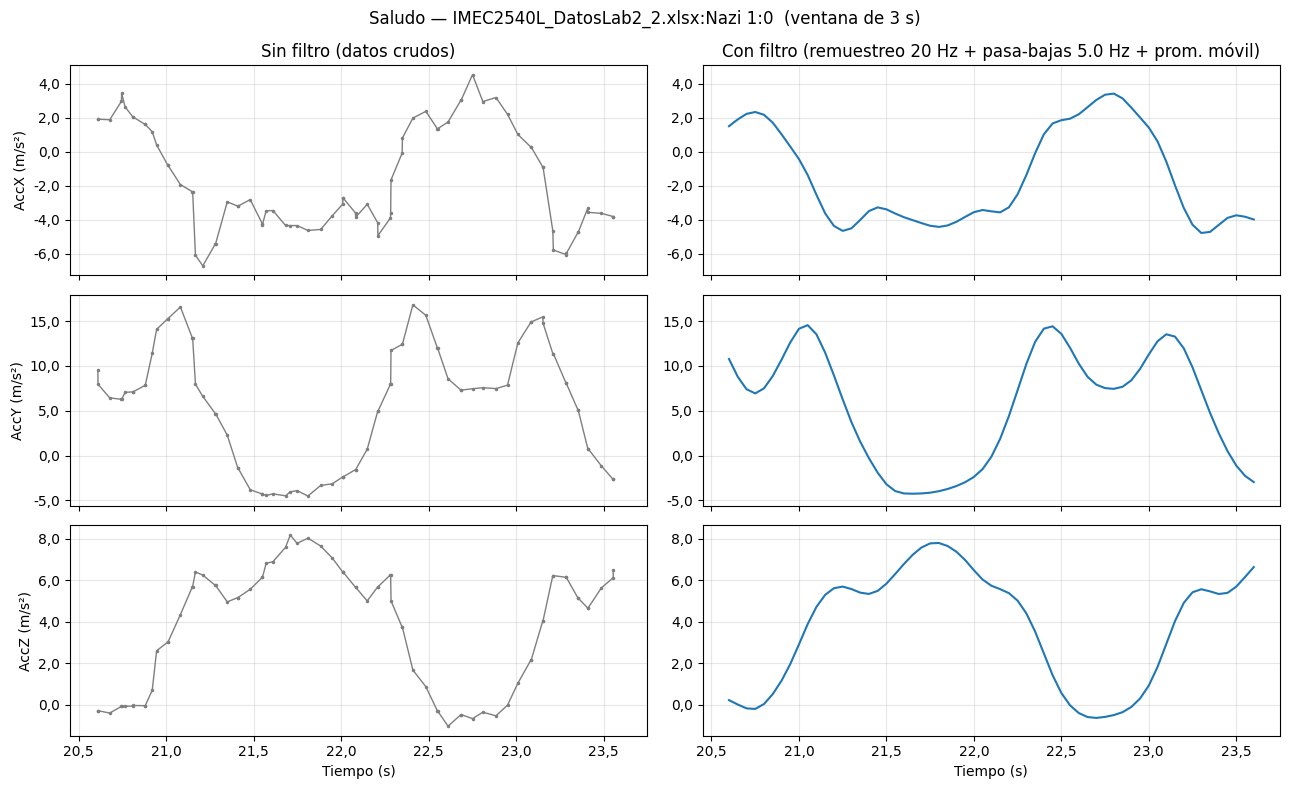

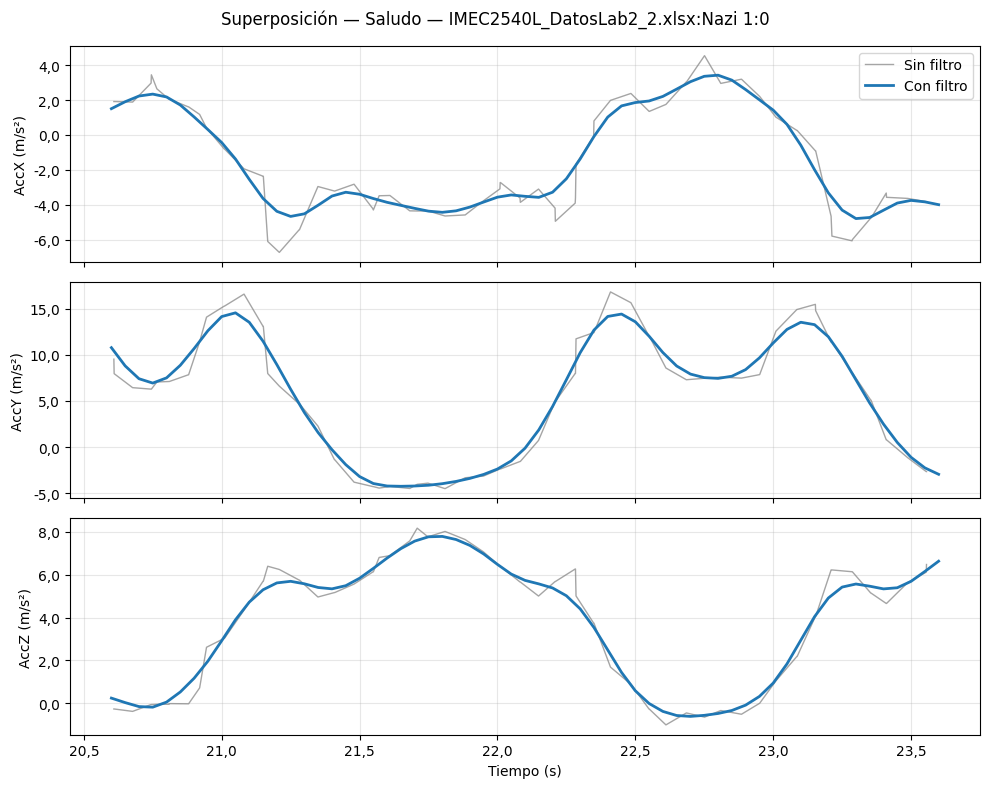

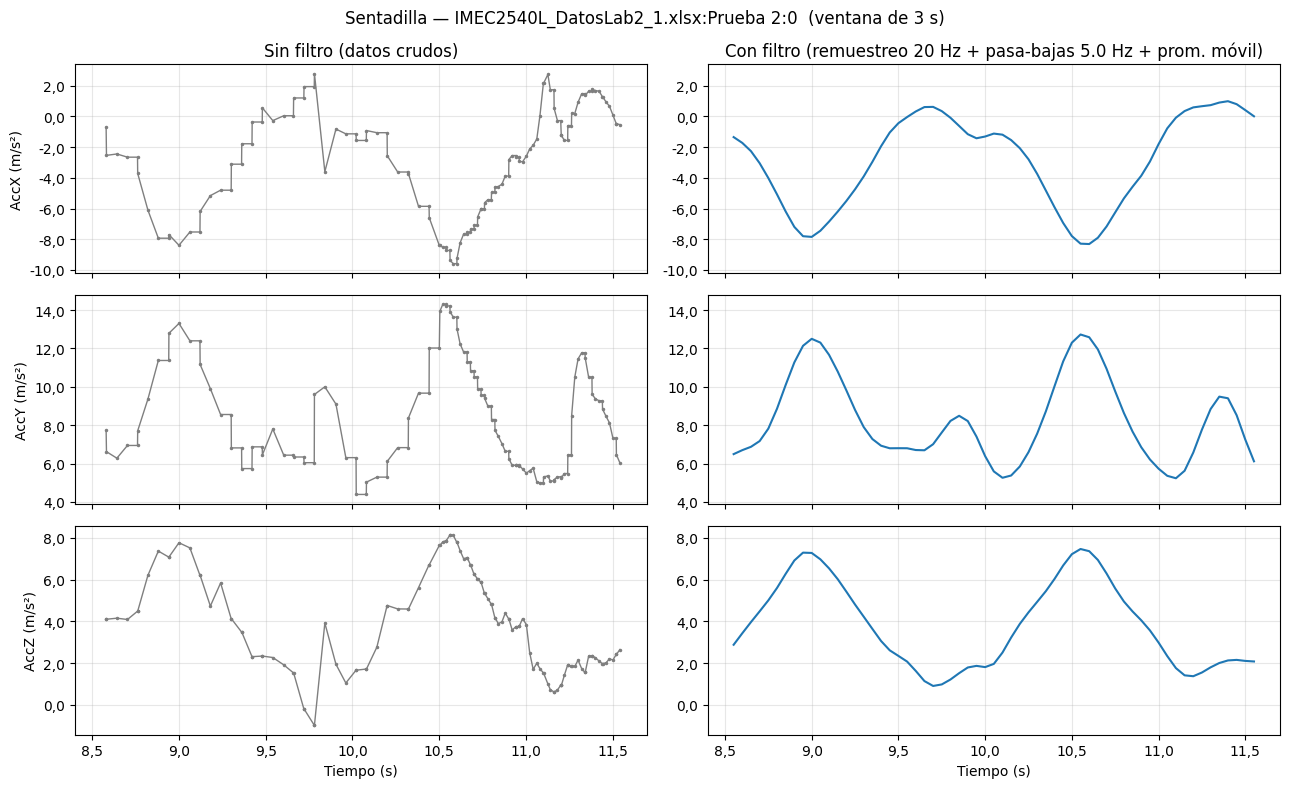

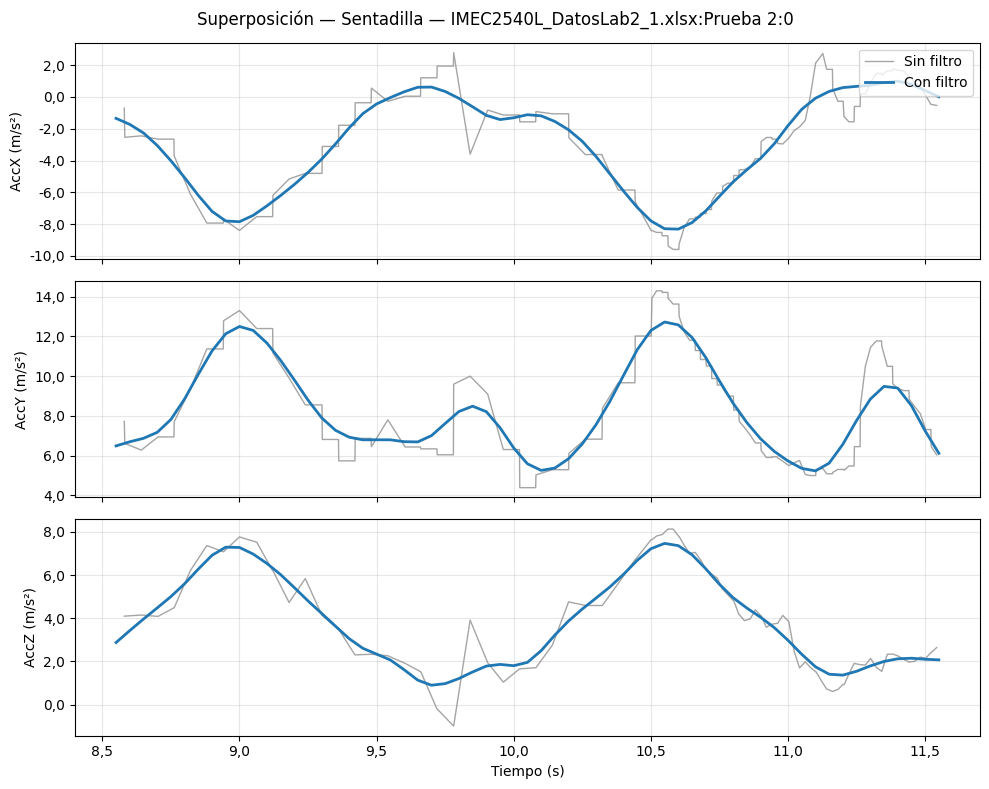

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Formato con coma decimal
coma = FuncFormatter(lambda v, _: f"{v:.1f}".replace(".", ","))

def extraer_ventana(idx, t_inicio=None):
    """Devuelve (crudo_recortado, t_filtrado, X_filtrado, etiqueta, id) para la serie idx."""
    df_raw, etiqueta, id_serie = series[idx]
    t_f, Xs, _, _ = series_filt[idx]
    t_r, _, _, _ = series_rec[idx]

    t0 = t_r[0] if t_inicio is None else t_inicio   # inicio de la actividad
    t1 = t0 + size_ventana                          # ventana de 3 s

    m_raw = (df_raw[col_tiempo] >= t0) & (df_raw[col_tiempo] <= t1)
    m_f   = (t_f >= t0) & (t_f <= t1)

    return df_raw[m_raw], t_f[m_f], Xs[m_f], etiqueta, id_serie

def graficar_muestra(idx, t_inicio=None):
    raw, t_f, X_f, etiqueta, id_serie = extraer_ventana(idx, t_inicio)

    fig, axs = plt.subplots(3, 2, figsize=(13, 8), sharex=True)
    fig.suptitle(f"{etiqueta} — {id_serie}  (ventana de {size_ventana:.0f} s)", fontsize=12)

    for j, (col, nom) in enumerate(zip(cols_aceleraciones, ["X", "Y", "Z"])):
        # Columna 0: sin filtro
        axs[j, 0].plot(raw[col_tiempo], raw[col], color="tab:gray", lw=1, marker=".", ms=3)
        axs[j, 0].set_ylabel(f"Acc{nom} (m/s²)")
        # Columna 1: con filtro
        axs[j, 1].plot(t_f, X_f[:, j], color="tab:blue", lw=1.5)

        # Misma escala vertical en ambas columnas para compararlas
        lo = min(raw[col].min(), X_f[:, j].min())
        hi = max(raw[col].max(), X_f[:, j].max())
        for k in (0, 1):
            axs[j, k].set_ylim(lo - 0.05*(hi-lo), hi + 0.05*(hi-lo))
            axs[j, k].yaxis.set_major_formatter(coma)
            axs[j, k].xaxis.set_major_formatter(coma)
            axs[j, k].grid(alpha=0.3)

    axs[0, 0].set_title("Sin filtro (datos crudos)")
    axs[0, 1].set_title(f"Con filtro (remuestreo {FS} Hz + pasa-bajas {FC} Hz + prom. móvil)")
    axs[2, 0].set_xlabel("Tiempo (s)")
    axs[2, 1].set_xlabel("Tiempo (s)")
    plt.tight_layout()
    plt.show()

    # Versión superpuesta (crudo vs filtrado en la misma gráfica)
    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f"Superposición — {etiqueta} — {id_serie}", fontsize=12)
    for j, (col, nom) in enumerate(zip(cols_aceleraciones, ["X", "Y", "Z"])):
        axs[j].plot(raw[col_tiempo], raw[col], color="tab:gray", alpha=0.7, lw=1, label="Sin filtro")
        axs[j].plot(t_f, X_f[:, j], color="tab:blue", lw=2, label="Con filtro")
        axs[j].set_ylabel(f"Acc{nom} (m/s²)")
        axs[j].yaxis.set_major_formatter(coma)
        axs[j].grid(alpha=0.3)
    axs[0].legend(loc="upper right")
    axs[2].set_xlabel("Tiempo (s)")
    axs[2].xaxis.set_major_formatter(coma)
    plt.tight_layout()
    plt.show()

# --- Seleccionar 2 muestras: la primera serie de cada una de estas etiquetas ---
etiquetas_demo = ["Saludo", "Sentadilla"]      # cámbialas por las que quieras
idx_demo = [next(i for i, s in enumerate(series) if s[1] == e) for e in etiquetas_demo]

for idx in idx_demo:
    graficar_muestra(idx)

### Parte 4. Extracción de Características

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

def extraer_features_ventana(w, fs=20):
    # w tiene forma (60, 3)
    feats = []

    # 1. Magnitud vectorial combinada
    mag = np.linalg.norm(w, axis=1) # Forma (60,)

    # Canales a procesar: X, Y, Z + Magnitud
    canales = [w[:, 0], w[:, 1], w[:, 2], mag]

    for c in canales:
        # Dominio del Tiempo
        mean_val = np.mean(c)
        std_val  = np.std(c)
        min_val  = np.min(c)
        max_val  = np.max(c)
        iqr_val  = stats.iqr(c)
        mad_val  = np.median(np.abs(c - np.median(c)))
        rms_val  = np.sqrt(np.mean(c**2))
        skew_val = stats.skew(c)
        kurt_val = stats.kurtosis(c)
        zcr_val  = np.sum(np.diff(c > mean_val) != 0)

        # Dominio de la Frecuencia (FFT)
        fft_vals = np.abs(np.fft.rfft(c))[1:] # Omitimos el componente DC (índice 0)
        freqs    = np.fft.rfftfreq(len(c), d=1/fs)[1:]

        energy_val   = np.sum(fft_vals**2)
        peak_freq    = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0
        centroid_val = np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8)

        feats.extend([
            mean_val, std_val, min_val, max_val, iqr_val, mad_val,
            rms_val, skew_val, kurt_val, zcr_val,
            energy_val, peak_freq, centroid_val
        ])

    # SMA (Signal Magnitude Area) global de los 3 ejes
    sma_val = np.mean(np.sum(np.abs(w), axis=1))
    feats.append(sma_val)

    return np.array(feats)

# Generación de nombres de columnas
metricas = ['mean', 'std', 'min', 'max', 'iqr', 'mad', 'rms', 'skew', 'kurtosis', 'zcr', 'fft_energy', 'fft_peak_freq', 'fft_centroid']
ejes = ['x', 'y', 'z', 'mag']

col_names = [f"{eje}_{m}" for eje in ejes for m in metricas] + ['sma']

# Extraer de todas las ventanas
X_features = np.array([extraer_features_ventana(w) for w in ventanas])
df_features = pd.DataFrame(X_features, columns=col_names)

In [ ]:
import numpy as np

# Definir diccionario a mano
label_dict = {
    'Angelito': 0,
    'Sentadilla': 1,
    'Saludo': 2,
    'Quieto': 3
}
'Angelito','Sentadilla','Saludo','Quieto'

# Codificar las etiquetas numéricamente
y_encoded = np.array([label_dict[etiqueta] for etiqueta in etiquetas])

In [ ]:
print(X_features)

[[-2.51288328e+00  3.51836280e+00 -1.06293265e+01 ...  2.33333333e+00
   2.52823371e+00  1.56175017e+01]
 [-3.32744477e+00  3.25297891e+00 -1.06293265e+01 ...  2.66666667e+00
   2.69114231e+00  1.66492163e+01]
 [-3.62225841e+00  3.10863031e+00 -9.58930674e+00 ...  2.66666667e+00
   3.11653519e+00  1.66714735e+01]
 ...
 [-9.80963338e-03  7.00678779e-03 -2.83536019e-02 ...  6.66666667e-01
   1.73415977e+00  1.02579523e+01]
 [-9.16796458e-03  7.61964599e-03 -2.83536019e-02 ...  3.33333333e-01
   2.43474550e+00  1.02532717e+01]
 [-1.12043409e-02  1.29316179e-02 -3.88388469e-02 ...  3.33333333e-01
   2.50544349e+00  1.02465746e+01]]


### Parte 5. Entrenamiento del Modelo (Método A)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df_features['target'] = y_encoded

# 1. Separar características (X) y etiqueta objetivo (y)
# Reemplaza 'target' por el nombre exacto de tu columna objetivo
X = df_features.drop(columns=['target'])
y = df_features['target']

# 2. Dividir los datos en conjuntos de Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Escalado de características (CRÍTICO para MLP)
# Las redes neuronales son muy sensibles a la escala de los datos (gradientes descendentemente estables)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Definir e instanciar el modelo MLPClassifier
# Puedes ajustar la arquitectura con `hidden_layer_sizes`
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50), # Dos capas ocultas: la primera de 100 neuronas, la segunda de 50
    activation='relu',            # Función de activación ('relu', 'tanh', 'logistic')
    solver='adam',                # Optimizador ('adam', 'sgd')                # Muestra el avance por época
)

# 5. Entrenar el modelo
mlp.fit(X_train_scaled, y_train)

# 6. Realizar predicciones
y_pred = mlp.predict(X_test_scaled)

# 7. Evaluar el desempeño
print("\n--- Resultados del Modelo A ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))



--- Resultados del Modelo A ---
Accuracy: 0.9968354430379747

Matriz de Confusión:
 [[163   0   0   0]
 [  0 165   0   0]
 [  0   0 118   2]
 [  0   0   0 184]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       163
           1       1.00      1.00      1.00       165
           2       1.00      0.98      0.99       120
           3       0.99      1.00      0.99       184

    accuracy                           1.00       632
   macro avg       1.00      1.00      1.00       632
weighted avg       1.00      1.00      1.00       632



## Metodo B

In [ ]:
### Método B: datos sin pasa-bajas ni promedio móvil + MLP tanh (16, 32, 16)

#Remuestreamos a 20 Hz sin filtros, recortado al mismo intervalo que usa el Método A
ventanas_nf, etiquetas_nf = [], []
for (df, etiqueta, id_serie), (t_r, _, _, _) in zip(series, series_rec):
    t = df[col_tiempo].values
    t_unif = np.arange(t[0], t[-1], 1 / FS)
    X_raw = np.column_stack([np.interp(t_unif, t, df[c].values) for c in cols_aceleraciones])

    # Mismo recorte temporal que series_rec, pero con datos ruidosos
    m = (t_unif >= t_r[0] - 1e-9) & (t_unif <= t_r[-1] + 1e-9)
    X_raw = X_raw[m]
    assert len(X_raw) == len(t_r), f"Longitud distinta en {id_serie}"

    W = ventanear(X_raw)
    ventanas_nf.append(W)
    etiquetas_nf += [etiqueta] * len(W)

ventanas_nf = np.concatenate(ventanas_nf)
assert ventanas_nf.shape == ventanas.shape, "El número de ventanas no coincide con el Método A"

#Características y etiquetas
X_nf = pd.DataFrame([extraer_features_ventana(w) for w in ventanas_nf], columns=col_names)
y_nf = np.array([label_dict[e] for e in etiquetas_nf])

#Misma partición que el Método A (mismos parámetros y mismo y => mismos índices)
Xtr_nf, Xte_nf, ytr_nf, yte_nf = train_test_split(
    X_nf, y_nf, test_size=0.1, random_state=42, stratify=y_nf
)

#Escalado propio (ajustado solo con train de B)
scaler_nf = StandardScaler()
Xtr_nf_s = scaler_nf.fit_transform(Xtr_nf)
Xte_nf_s = scaler_nf.transform(Xte_nf)

#Modelo B
mlp_B = MLPClassifier(
    hidden_layer_sizes=(16, 32, 16),
    activation='tanh',
    solver='sgd',
    max_iter=300,
    random_state=42
)
mlp_B.fit(Xtr_nf_s, ytr_nf)
y_pred_B = mlp_B.predict(Xte_nf_s)

#Desempeño

print("\n--- Resultados Método B (sin filtro, tanh, (16, 32, 16)) ---")
print("Accuracy:", accuracy_score(yte_nf, y_pred_B))
print("\nMatriz de Confusión:\n", confusion_matrix(yte_nf, y_pred_B))
print("\nReporte de Clasificación:\n", classification_report(yte_nf, y_pred_B))



--- Resultados Método B (sin filtro, tanh, (16, 32, 16)) ---
Accuracy: 0.9873417721518988

Matriz de Confusión:
 [[80  0  0  1]
 [ 0 83  0  0]
 [ 2  0 58  0]
 [ 1  0  0 91]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98        81
           1       1.00      1.00      1.00        83
           2       1.00      0.97      0.98        60
           3       0.99      0.99      0.99        92

    accuracy                           0.99       316
   macro avg       0.99      0.99      0.99       316
weighted avg       0.99      0.99      0.99       316



Datos requeridos para el informe

In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Tiempo de Entrenamiento (Método A)
t0 = time.time()
mlp.fit(X_train_scaled, y_train)
t_train_A = time.time() - t0

# Tiempo de Inferencia (Método A)
t0 = time.time()
y_pred_A = mlp.predict(X_test_scaled)
t_infer_A = (time.time() - t0) / len(X_test_scaled) * 1000  # ms por muestra/serie

# Cálculo de Métricas (Método A)
acc_A  = accuracy_score(y_test, y_pred_A)
prec_A = precision_score(y_test, y_pred_A, average='macro')
rec_A  = recall_score(y_test, y_pred_A, average='macro')
f1_A   = f1_score(y_test, y_pred_A, average='macro')

# Tiempo de Entrenamiento (Método B)
t0 = time.time()
mlp_B.fit(Xtr_nf_s, ytr_nf)
t_train_B = time.time() - t0

# Tiempo de Inferencia (Método B)
t0 = time.time()
y_pred_B = mlp_B.predict(Xte_nf_s)
t_infer_B = (time.time() - t0) / len(Xte_nf_s) * 1000  # ms por muestra/serie

# Cálculo de Métricas (Método B)
acc_B  = accuracy_score(yte_nf, y_pred_B)
prec_B = precision_score(yte_nf, y_pred_B, average='macro')
rec_B  = recall_score(yte_nf, y_pred_B, average='macro')
f1_B   = f1_score(yte_nf, y_pred_B, average='macro')

# 3. TABLA COMPARATIVA DE RESULTADOS

df_resultados = pd.DataFrame({
    'Métrica': [
        'Accuracy',
        'F1-macro',
        'Precisión (macro)',
        'Recall (macro)',
        'Tiempo de entrenamiento [s]',
        'Tiempo de inferencia [ms/serie]'
    ],
    'Método A': [
        f"{acc_A:.4f}",
        f"{f1_A:.4f}",
        f"{prec_A:.4f}",
        f"{rec_A:.4f}",
        f"{t_train_A:.4f} s",
        f"{t_infer_A:.4f} ms"
    ],
    'Método B': [
        f"{acc_B:.4f}",
        f"{f1_B:.4f}",
        f"{prec_B:.4f}",
        f"{rec_B:.4f}",
        f"{t_train_B:.4f} s",
        f"{t_infer_B:.4f} ms"
    ]
})

print("\n--- TABLA DE MÉTRICAS CUANTITATIVAS ---")
print(df_resultados.to_string(index=False))


--- TABLA DE MÉTRICAS CUANTITATIVAS ---
                        Métrica  Método A  Método B
                       Accuracy    0.9968    0.9873
                       F1-macro    0.9965    0.9869
              Precisión (macro)    0.9971    0.9882
                 Recall (macro)    0.9958    0.9859
    Tiempo de entrenamiento [s]  1.1466 s  5.4369 s
Tiempo de inferencia [ms/serie] 0.0031 ms 0.0079 ms


###Prueba de clasificación

Usamos el modelo A para la prueba de clasificación al tener mejor accuracy

Datos: 2870 filas, 99.6 s
movimiento  inicio_s  fin_s  duracion_s  confianza
  Angelito      0.00  15.88       15.88       0.86
Sentadilla     15.88  26.38       10.50       0.97
    Saludo     26.38  37.38       11.00       0.98
  Angelito     37.38  37.62        0.25       0.56
    Quieto     37.62  44.62        7.00       0.93
Sentadilla     44.62  55.88       11.25       0.97
  Angelito     55.88  68.62       12.75       0.95
    Quieto     68.62  75.62        7.00       0.92
    Saludo     75.62  92.62       17.00       0.96
    Quieto     92.62  96.62        4.00       0.78
  Angelito     96.62  99.55        2.93       0.43


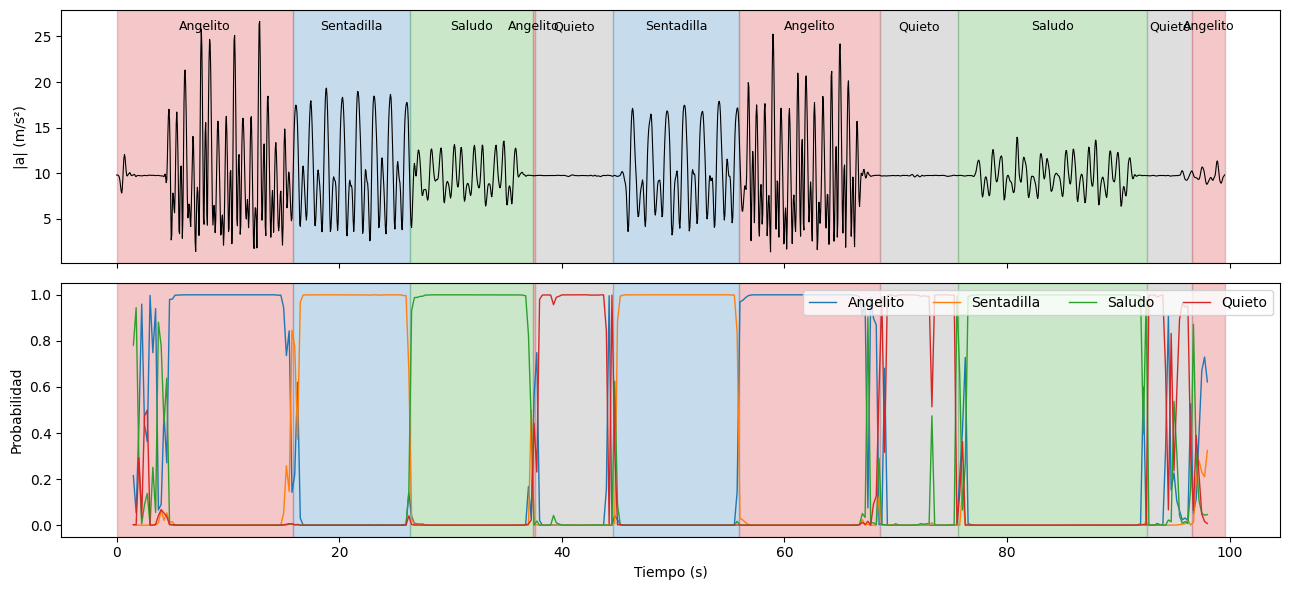

In [ ]:
# ===== Clasificar el Excel "Datos_para_pruebas.xlsx" con el modelo ya entrenado =====
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# 1. Leer la hoja con los datos completos (la que ya no tiene vacíos)
ruta = "Datos_para_pruebas.xlsx"
df_raw = pd.read_excel(ruta, sheet_name="Datos completos")

# Poner los nombres de columnas igual que en el entrenamiento y descartar el Timestamp
df_raw = df_raw.rename(columns={"AccX": cols_aceleraciones[0],
                                "AccY": cols_aceleraciones[1],
                                "AccZ": cols_aceleraciones[2]})
df = limpiar(df_raw)                       # TU función: se queda con tiempo + 3 ejes, quita repetidos y ordena
print(f"Datos: {len(df)} filas, {df[col_tiempo].iloc[-1]:.1f} s")

# 2. Remuestrear + pasa-bajos + promedio móvil (TU función; aquí NO se recorta el reposo)
t_unif, Xf, Xs = remuestrear_y_filtrar(df)

# 3. Ventanas de 3 s (TU función), deslizando cada 0.25 s para localizar mejor el tiempo
PASO = int(0.25 * FS)
W = ventanear(Xs, win=WIN, step=PASO)                      # (n_ventanas, 60, 3)
inicios = np.arange(0, len(Xs) - WIN + 1, PASO)
t_centro = t_unif[inicios + WIN // 2]                      # instante central de cada ventana

# 4. Features (TU función) -> escalar (TU scaler) -> predecir (TU mlp)
F = pd.DataFrame([extraer_features_ventana(w) for w in W], columns=col_names)
P = mlp.predict_proba(scaler.transform(F))
pred = P.argmax(axis=1)
nombre = {v: k for k, v in label_dict.items()}

# 5. Quitar parpadeos: cada ventana toma la etiqueta más frecuente de sus 7 vecinas (~1.75 s)
r = 3
pred = np.array([np.bincount(pred[max(0, i - r): i + r + 1]).argmax() for i in range(len(pred))])

# 6. Agrupar ventanas consecutivas iguales en tramos de tiempo
tramos, i = [], 0
while i < len(pred):
    j = i
    while j + 1 < len(pred) and pred[j + 1] == pred[i]:
        j += 1
    ini = t_unif[0] if i == 0 else (t_centro[i - 1] + t_centro[i]) / 2
    fin = t_unif[-1] if j == len(pred) - 1 else (t_centro[j] + t_centro[j + 1]) / 2
    tramos.append({"movimiento": nombre[pred[i]], "inicio_s": round(ini, 2), "fin_s": round(fin, 2),
                   "duracion_s": round(fin - ini, 2), "confianza": round(P[i:j + 1, pred[i]].mean(), 2)})
    i = j + 1
resultado = pd.DataFrame(tramos)
print(resultado.to_string(index=False))

# 7. Gráfica: señal con cada tramo coloreado + probabilidades
colores = {"Angelito": "tab:red", "Sentadilla": "tab:blue", "Saludo": "tab:green", "Quieto": "tab:gray"}
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(t_unif, np.linalg.norm(Xs, axis=1), "k", lw=0.8); ax[0].set_ylabel("|a| (m/s²)")
for _, f in resultado.iterrows():
    for a in ax:
        a.axvspan(f.inicio_s, f.fin_s, color=colores[f.movimiento], alpha=0.25)
    ax[0].text((f.inicio_s + f.fin_s) / 2, ax[0].get_ylim()[1] * 0.92, f.movimiento, ha="center", fontsize=9)
for k in range(P.shape[1]):
    ax[1].plot(t_centro, P[:, k], label=nombre[k], lw=1)
ax[1].set_ylabel("Probabilidad"); ax[1].set_xlabel("Tiempo (s)"); ax[1].legend(ncol=4, loc="upper right")
plt.tight_layout(); plt.show()